In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
# plot_utils.linclab_plt_defaults(font="Arial", fontdir="fonts")
from matplotlib.pyplot import cm
import re
import math
import matplotlib.gridspec as gridspec
import json
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

api = wandb.Api(timeout=19)

/home/mila/r/roy.eyono/inhibitory-normalization/.venv/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/mila/r/roy.eyono/inhibitory-normalization/.venv/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by as

In [2]:
import pandas as pd
from matplotlib.ticker import ScalarFormatter

In [3]:
# Fetch runs for a specific project
def fetch_runs(api, entity, project_name, filters, order=None):
    if order:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, order=order)
    else:
        runs = api.runs(f"{entity}/{project_name}", filters=filters)
    #print(f"Runs for project '{project_name}':")
    return runs

In [4]:
def same_config(config1, config2, keys=['normtype']):
    for key in keys:
        if config1[key] != config2[key]:
            return False
    return True

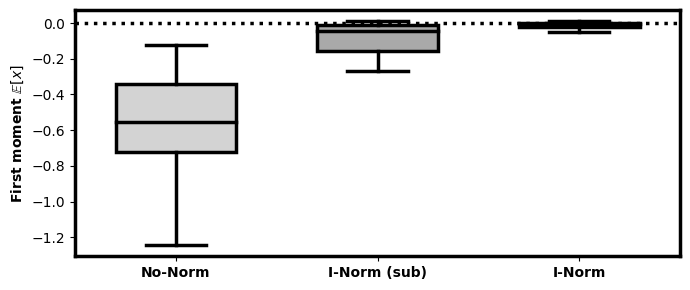

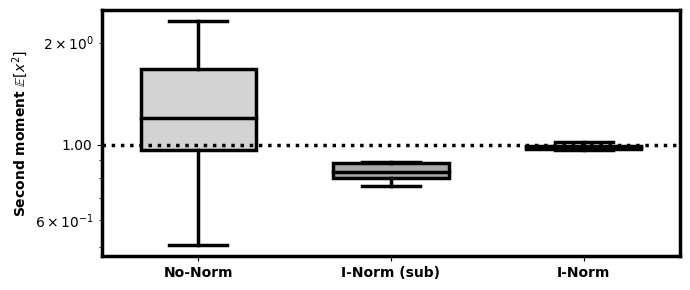

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mu_var_boxplot_comparison(epsilons):
    ln_feedback_types = ['No-Norm', 'I-Norm (sub)', 'I-Norm']
    # strictly black and white/grayscale palette
    colors = {'I-Norm': 'white', 'No-Norm': 'lightgray', 'I-Norm (sub)': 'darkgray'}
    edge_color = 'black'
    lw = 2.5  # Base line thickness

    mu_data = {t: [] for t in ln_feedback_types}
    var_data = {t: [] for t in ln_feedback_types}

    for epsilon in epsilons:
        for ln_fdb in ln_feedback_types:
            if ln_fdb == 'I-Norm (sub)':
                # Keeping your specific epsilon mapping logic
                query_eps = 1 if epsilon == 0.25 else epsilon
                project = 'Luminosity_NAISYS'
                filters = {
                    "config.dataset": "fashionmnist",
                    "config.brightness_factor": query_eps,
                    "config.homeostasis": 1,
                    "config.shunting": None, 
                    "config.use_testset": True,
                    "config.is_dann": 1,
                    "config.normtype": 0,
                }
            else:
                project = 'Luminosity_LNHomeostasis'
                filters = {
                    "config.dataset": "fashionmnist",
                    "config.brightness_factor": epsilon,
                    "config.homeostasis": 1 if ln_fdb == 'I-Norm' else 0,
                    "config.normtype": 0,
                    "config.normtype_detach": 1,
                    "config.excitation_training": 1 if ln_fdb == 'I-Norm' else 0,
                    "config.layer_norm": None if ln_fdb == 'I-Norm' else 0,
                    "config.use_testset": True,
                    "config.lambda_homeo": 0.01 if ln_fdb == 'I-Norm' else 1,
                }

            runs = fetch_runs(
                api,
                entity='project_danns',
                project_name=project,
                filters=filters,
                order="-summary_metrics.test_acc"
            )[:10]

            for run in runs:
                try:
                    if ln_fdb == 'I-Norm (sub)':
                        mu0 = float(run.summary.get("train_fc1_mu", np.nan))
                        mu1 = float(run.summary.get("train_fc1_mu", np.nan))
                        var0 = float(run.summary.get("train_fc1_var", np.nan))
                        var1 = float(run.summary.get("train_fc1_var", np.nan))
                    else:
                        mu0 = float(run.summary.get("train_fc0_mu", np.nan))
                        mu1 = float(run.summary.get("train_fc1_mu", np.nan))
                        var0 = float(run.summary.get("train_fc0_var", np.nan))
                        var1 = float(run.summary.get("train_fc1_var", np.nan))
                except (TypeError, ValueError):
                    continue

                if not np.any(np.isnan([mu0, mu1, var0, var1])):
                    mu_data[ln_fdb].append((mu0 + mu1) / 2)
                    var_data[ln_fdb].append((var0 + var1) / 2)

    def create_boxplot(data_dict, ylabel, filename, y_hline=None, use_log=False):
        fig, ax = plt.subplots(figsize=(7, 3))
        plot_list = [data_dict[t] for t in ln_feedback_types]
        
        # Modified for thickness and BW style
        bp = ax.boxplot(
            plot_list, 
            patch_artist=True,
            widths=0.6,
            showfliers=False,  # REMOVE OUTLIERS
            boxprops=dict(linewidth=lw, color=edge_color),
            whiskerprops=dict(linewidth=lw, color=edge_color),
            capprops=dict(linewidth=lw, color=edge_color),
            medianprops=dict(linewidth=lw, color=edge_color), # BLACK MEDIAN
        )

        for patch, t in zip(bp['boxes'], ln_feedback_types):
            patch.set_facecolor(colors[t])

        if y_hline is not None:
            ax.axhline(y_hline, color='black', linestyle='dotted', linewidth=lw)

        ax.set_xticklabels(ln_feedback_types, fontweight='bold')
        ax.set_ylabel(ylabel, fontweight='bold')
        
        # Make axes spines thicker
        for spine in ax.spines.values():
            spine.set_linewidth(lw)

        if use_log:
            ax.set_yscale("log")
            ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

        plt.tight_layout()
        plt.savefig(filename, format="svg")
        plt.show()

    # Generate plots
    create_boxplot(mu_data, r"First moment $\mathbb{E}[x]$", "fig_mu_bw.svg", y_hline=0)
    create_boxplot(var_data, r"Second moment $\mathbb{E}[x^2]$", "fig_var_bw.svg", y_hline=1, use_log=True)

# Usage
epsilons = [0.0, 0.25, 0.5, 0.75]
plot_mu_var_boxplot_comparison(epsilons)